Original variance: [2.57675126 2.62529399]
Projected variance: 4.162563894040794


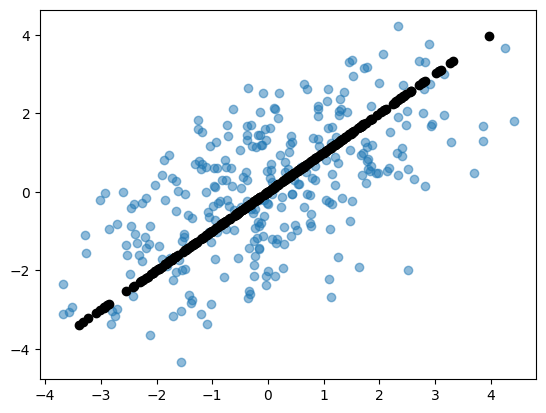

In [14]:
#Assignment 1: Geometry of PCA  

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(20)
mean = [0, 0]
cov = [[3 , 2], [2, 3]]
X = np.random.multivariate_normal(mean, cov, 300)

v = np.array([1, 1])
v = v / np.linalg.norm(v)

projection = X @ v
projected_points = np.outer(projection, v)

print("Original variance:", np.var(X, axis=0))
print("Projected variance:", np.var(projection))

plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.scatter(projected_points[:,0], projected_points[:,1], color='black')
plt.show()


Eigenvalues: [1.00000000e+00 1.11022302e-16]
Eigenvectors:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


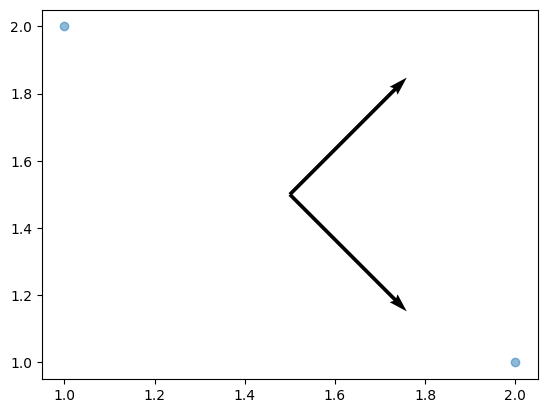

In [18]:
#Assignment 2: Eigenvalues = Variance  

# Define transformation matrix
X = np.array([[2, 3],
              [3, 2]])

cov_matrix = np.cov(X.T)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eig_vals)
print("Eigenvectors:\n", eig_vecs)

plt.scatter(X[:,0], X[:,1], alpha=0.5)
origin = np.mean(X, axis=0)
for i in range(2):
    plt.quiver(origin[0], origin[1],
               eig_vecs[0,i], eig_vecs[1,i],
               scale=3)
plt.show()



eig_vals [3.39453522 2.36827261]
eig_vals [[-0.89438306  0.44730184]
 [-0.44730184 -0.89438306]]


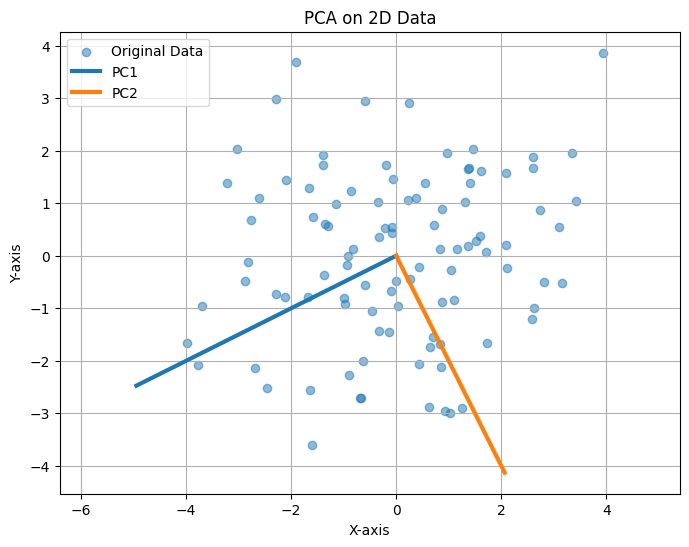

In [19]:
#Assignment 3: Build PCA Step-by-Step  
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D data
np.random.seed(42)

mean = [0, 0]
cov = [[4, 1], [1, 3]]  # Covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

# Center the data
X_centered = X - np.mean(X, axis=0)

# Compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)


# Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]


print('eig_vals',eig_vals)
print('eig_vals',eig_vecs)


# Project data onto principal components
X_pca = X_centered @ eig_vecs

# Plot original data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label="Original Data")
for i in range(2):
    vec = eig_vecs[:, i] * np.sqrt(eig_vals[i]) * 3  # scale for visibility
    plt.plot([0, vec[0]], [0, vec[1]], linewidth=3, label=f"PC{i+1}")
plt.axis('equal')
plt.title("PCA on 2D Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#Assignment 4: Visual Understanding of PCA Rotation

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

components = pca.components_
print(components)
# Plot original axes and principal components using quiver()




[[ 0.89438306  0.44730184]
 [-0.44730184  0.89438306]]


Reconstruction Error: 1.1722949409236727


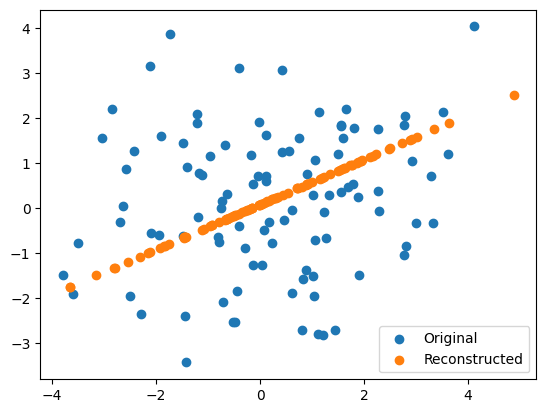

In [22]:
#Assignment 5: Reconstruction Error
pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)
X_reconstructed = pca.inverse_transform(X_reduced)

error = np.mean((X - X_reconstructed)**2)
print("Reconstruction Error:", error)

plt.scatter(X[:,0], X[:,1], label="Original")
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
            label="Reconstructed")
plt.legend()
plt.show()


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = np.array([[1,1000],
              [2,2000],
              [3,3000],
              [4,4000]])

pca1 = PCA().fit(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca2 = PCA().fit(X_scaled)

print("Without Scaling:", pca1.components_)
print("With Scaling:", pca2.components_)



Without Scaling: [[ 0.001      0.9999995]
 [ 0.9999995 -0.001    ]]
With Scaling: [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [26]:
pca = PCA()
pca.fit(X)

manual_ratio = pca.explained_variance_ / \
               np.sum(pca.explained_variance_)

print("Manual Ratio:", manual_ratio)
print("Sklearn Ratio:", pca.explained_variance_ratio_)



Manual Ratio: [1. 0.]
Sklearn Ratio: [1. 0.]


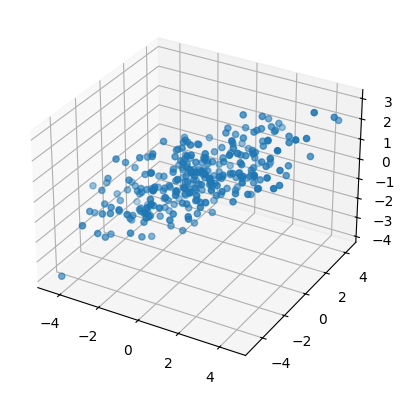

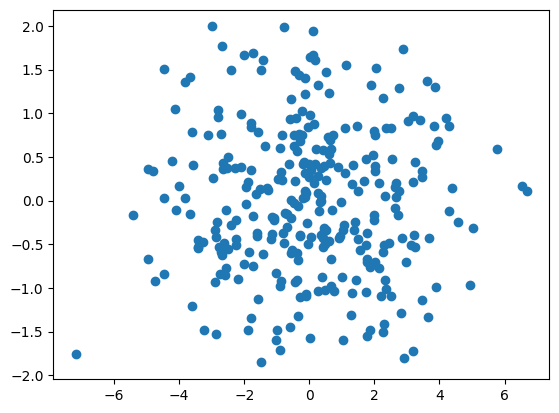

In [30]:
from mpl_toolkits.mplot3d import Axes3D

X3 = np.random.multivariate_normal(
    [0,0,0],
    [[3,2,1],[2,2,1],[1,1,1]],
    300
)


pca = PCA(n_components=2)
X2 = pca.fit_transform(X3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2])

plt.figure()
plt.scatter(X2[:,0], X2[:,1])
plt.show()


In [32]:
original_size = X.nbytes

pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)
compressed_size = X_reduced.nbytes

X_reconstructed = pca.inverse_transform(X_reduced)
error = np.mean((X - X_reconstructed)**2)

print("Original Size:", original_size)
print("Compressed Size:", compressed_size)
print("Reconstruction Error:", error)


Original Size: 64
Compressed Size: 32
Reconstruction Error: 5.816118612394133e-26
